<a href="https://colab.research.google.com/github/DifferentiableUniverseInitiative/JaxPM/blob/main/notebooks/01-Introduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [106]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "6"

In [107]:
# Installing JaxPM
# !pip install --quiet --upgrade jax
# !pip install --quiet jaxpm

In [108]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [109]:
if 'debug' not in globals():
    debug = True
    import debugpy
    debugpy.listen(('127.0.0.1', 5678))

In [110]:
import jax
import jax.numpy as jnp
import jax_cosmo as jc

from jax.experimental.ode import odeint

from jaxpm.painting import cic_paint
from jaxpm.pm import linear_field, lpt, make_avera_ode, make_t_ode

import matplotlib.pyplot as plt

In [111]:
# 1 Mpc coarse graining scale
# mesh_shape = [128, 128, 128]
# box_size = [128., 128., 128.]

# mesh_shape = [192, 192, 192]
# box_size = [192., 192., 192.]

# mesh_shape = [128, 128, 128]
# box_size = [80., 80., 80.]

# mesh_shape = [192, 192, 192]
# box_size = [80., 80., 80.]

# mesh_shape = [128, 128, 128]
# box_size = [192., 192., 192.]

mesh_shape = [128, 128, 128]
box_size = [96., 96., 96.]

k = jnp.logspace(-4, 1, 128)
pk = jc.power.linear_matter_power(jc.Planck15(), k)
pk_fn = lambda x: jnp.interp(x.reshape([-1]), k, pk).reshape(x.shape)
initial_conditions = linear_field(mesh_shape, box_size, pk_fn, seed=jax.random.PRNGKey(10))
particles = jnp.stack(jnp.meshgrid(*[jnp.arange(s) for s in mesh_shape]),axis=-1).reshape([-1,3])

/datascope/slurm/miniconda3/envs/dobos-jax/lib/python3.13/site-packages/jax/_src/numpy/array_methods.py:122: UserWarning: Explicitly requested dtype <class 'jax.numpy.int64'> requested in astype is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


In [112]:
a = 0.1
# snapshots = jnp.array([a, 0.5, 0.7, 0.9, 1.0, 1.05, 1.1])
snapshots = jnp.linspace(a, 1.1, 100)

@jax.jit
def run_simulation(): # omega_c, sigma8):
    cosmo = jc.EdS()

    # Evolve the simulation forward
    res = odeint(make_t_ode(), [(2/3) * a**(3/2)], snapshots, cosmo,
                 rtol=1e-8,
                 atol=1e-8)

    # Return the simulation volume at requested timesteps
    return res[0]

In [113]:
t = run_simulation()

a: 0.10000000149011612, t: [Array(0.02108185, dtype=float32)]
a: 0.10066666454076767, t: [Array(0.02129267, dtype=float32)]
a: 0.10183312743902206, t: [Array(0.02166154, dtype=float32)]
a: 0.10274969041347504, t: [Array(0.02195733, dtype=float32)]
a: 0.1073324978351593, t: [Array(0.02344259, dtype=float32)]
a: 0.10814721882343292, t: [Array(0.02371, dtype=float32)]
a: 0.10916562378406525, t: [Array(0.02404569, dtype=float32)]
a: 0.10916562378406525, t: [Array(0.02404571, dtype=float32)]
a: 0.11597716808319092, t: [Array(0.02629626, dtype=float32)]
a: 0.11938294768333435, t: [Array(0.02749933, dtype=float32)]
a: 0.13641181588172913, t: [Array(0.03358757, dtype=float32)]
a: 0.1394391655921936, t: [Array(0.03471026, dtype=float32)]
a: 0.1432233601808548, t: [Array(0.03613271, dtype=float32)]
a: 0.1432233601808548, t: [Array(0.03613512, dtype=float32)]
a: 0.15490542352199554, t: [Array(0.04055618, dtype=float32)]
a: 0.16074645519256592, t: [Array(0.04296558, dtype=float32)]
a: 0.1899516284

In [114]:
snapshots, t

(Array([0.1       , 0.11010101, 0.12020202, 0.13030304, 0.14040405,
        0.15050505, 0.16060606, 0.17070708, 0.18080808, 0.19090909,
        0.20101011, 0.21111111, 0.22121212, 0.23131314, 0.24141414,
        0.25151515, 0.26161617, 0.2717172 , 0.28181818, 0.2919192 ,
        0.3020202 , 0.3121212 , 0.32222223, 0.33232325, 0.34242427,
        0.35252526, 0.36262628, 0.37272727, 0.3828283 , 0.39292932,
        0.4030303 , 0.41313133, 0.42323235, 0.43333334, 0.44343436,
        0.45353538, 0.46363637, 0.4737374 , 0.48383838, 0.4939394 ,
        0.5040404 , 0.51414144, 0.5242424 , 0.5343434 , 0.54444444,
        0.55454546, 0.5646465 , 0.57474744, 0.5848485 , 0.5949495 ,
        0.60505056, 0.6151515 , 0.62525254, 0.6353535 , 0.6454546 ,
        0.65555555, 0.66565657, 0.6757576 , 0.6858586 , 0.69595957,
        0.70606065, 0.7161616 , 0.7262626 , 0.73636365, 0.74646467,
        0.7565657 , 0.76666665, 0.77676773, 0.7868687 , 0.7969698 ,
        0.80707073, 0.81717175, 0.8272727 , 0.83

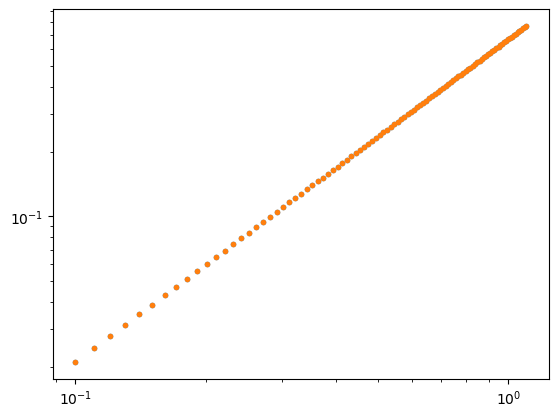

In [115]:
plt.loglog(snapshots, t, '.')
plt.loglog(snapshots, 2/3 * snapshots**(3/2), '.')

In [116]:
# (2/3) * 0.1**(3/2)
# 3/2 * 0.1**(3/2)

In [117]:
# Initial a where the simulation starts
a = 0.1
a_avera = 0.1

# These must be given in the variable we integrate over, i.e. in standard cosmology
# snapshots = jnp.array([0.1, 0.5, 1.0, 1.3, 1.5])
# snapshots = jnp.array([a, 0.2, 0.3, 0.4, 0.5, 0.7, 0.9, 1.0, 1.01, 1.02, 1.03, 1.04, 1.05])
snapshots = jnp.linspace(a, 1.05, 25)
# snapshots = jnp.array([1.1, 2.5, 5, 7, 10.0])

@jax.jit
def run_simulation(): # omega_c, sigma8):
    # Create a small function to generate the matter power spectrum
    # k = jnp.logspace(-4, 1, 128)
    # pk = jc.power.linear_matter_power(jc.Planck15(Omega_c=omega_c, sigma8=sigma8), k)
    # pk = jc.power.linear_matter_power(jc.EdS(), k)
    # pk_fn = lambda x: jnp.interp(x.reshape([-1]), k, pk).reshape(x.shape)

    # Create initial conditions and particles
    # initial_conditions = linear_field(mesh_shape, box_size, pk_fn, seed=jax.random.PRNGKey(10))
    # particles = jnp.stack(jnp.meshgrid(*[jnp.arange(s) for s in mesh_shape]),axis=-1).reshape([-1,3])

    # Initial displacement
    cosmo = jc.Planck15()

    # LPT takes the intial conditions at a=1, z=0 according to the cosmology
    # and transfers it back to the given a
    # H_0 of cosmo is used to calculate the initial conditions
    dx, p, f = lpt(cosmo, initial_conditions, particles, a=a)

    # Evolve the simulation forward
    # H_0 of cosmo is not used in what follows
    cosmo = jc.EdS()
    res = odeint(make_avera_ode(mesh_shape),
                 [
                     particles + dx,
                     p,
                     a_avera,
                     
                     # time
                     0.03777494,    # time at a=0.1 in Planck15 cosmology
                     # (2/3) * a**(3/2)
                ],
                 snapshots, snapshots[0], cosmo,
                 rtol=1e-10,
                 atol=1e-10)

    # Return the simulation volume at requested timesteps
    return initial_conditions,  particles + dx , res[0], res[2], res[3]

In [118]:
initial_conditions , lpt_particles , ode_particles, a_avg, t = run_simulation()

a, a_avera, 0.10000000149011612, 0.10000000149011612, 0, 0.0
a, a_avera, 0.10457930713891983, 0.10457933694124222, 0, 0.0
a, a_avera, 0.10013814270496368, 0.10013814270496368, 0, 0.0
a, a_avera, 0.10020720958709717, 0.10020720958709717, 0, 0.0
a, a_avera, 0.10055255144834518, 0.10055256634950638, 0, 0.0
a, a_avera, 0.10061394423246384, 0.10061396658420563, 0, 0.0
a, a_avera, 0.10069069266319275, 0.10069071501493454, 0, 0.0
a, a_avera, 0.10069069266319275, 0.10069070756435394, 0, 0.0
a, a_avera, 0.10083634406328201, 0.1008363589644432, 0, 0.0
a, a_avera, 0.10090916603803635, 0.10090918838977814, 0, 0.0
a, a_avera, 0.10127328336238861, 0.10127332806587219, 0, 0.0
a, a_avera, 0.10133801400661469, 0.10133806616067886, 0, 0.0
a, a_avera, 0.10141893476247787, 0.10141898691654205, 0, 0.0
a, a_avera, 0.10141893476247787, 0.10141898691654205, 0, 0.0
a, a_avera, 0.10156930983066559, 0.10156936943531036, 0, 0.0
a, a_avera, 0.10164449363946915, 0.10164456814527512, 0, 0.0
a, a_avera, 0.10202042758

In [119]:
# Save results
import numpy as np

# Columns: snapshot (integration a), time (EdS time), a_avg (a_avera)
data = np.stack([snapshots, t, a_avg], axis=-1)

# Save as csv
np.savetxt('avera_results.csv', data, delimiter=',', header='a,t_EdS,a_avera', comments='')

In [120]:
snapshots, a_avg, t

(Array([0.1       , 0.13958333, 0.17916667, 0.21875   , 0.25833333,
        0.29791665, 0.33749998, 0.37708333, 0.41666666, 0.45624998,
        0.49583334, 0.53541666, 0.575     , 0.6145833 , 0.6541667 ,
        0.69375   , 0.73333335, 0.7729166 , 0.81249994, 0.8520833 ,
        0.89166665, 0.93125   , 0.9708333 , 1.0104167 , 1.05      ],      dtype=float32),
 Array([0.1       , 0.13963908, 0.17944072, 0.21949093, 0.259883  ,
        0.3007149 , 0.34208465, 0.38408366, 0.42680132, 0.47031495,
        0.514697  , 0.56001365, 0.6063146 , 0.6536465 , 0.70204484,
        0.75153995, 0.8021519 , 0.8538931 , 0.90677357, 0.96080005,
        1.0159588 , 1.0722182 , 1.1295612 , 1.1879935 , 1.2475253 ],      dtype=float32),
 Array([0.03777494, 0.05145943, 0.06725168, 0.08490042, 0.1042276 ,
        0.12509881, 0.14740637, 0.17106393, 0.19599809, 0.2221464 ,
        0.24945533, 0.27787682, 0.30736846, 0.33789492, 0.36942145,
        0.40191555, 0.43535018, 0.46970004, 0.5049399 , 0.5410493 ,
    

In [121]:
from scipy.interpolate import interp1d
interp1d(a_avg, t)(1.0)

array(0.56731451)

In [122]:
# Using astropy, calculate the look back time as a function of the scale factor of LambdaCDM Planck15

from astropy.cosmology import Planck15
# from astropy import units as u
# import numpy as np
# a_vals = np.linspace(0.1, 1.0, 100)
# t_vals = Planck15.age(1/a_vals - 1).to(u.Gyr)
# H0 = Planck15.H0
# H0_inv_Gyr = (1 / H0).to(u.Gyr)
# t_vals_H0 = (t_vals / H0_inv_Gyr).value


# astropy Planck15 cosmology expands faster due to radiation at early times
# so it will expand faster than EdS
# needs to set cosmology manually in astropy


from astropy.cosmology import FlatLambdaCDM, w0waCDM
from astropy import units as u
import numpy as np
lcdm_cosmo = FlatLambdaCDM(H0=Planck15.H0, Om0=Planck15.Om0, Tcmb0=1e-8)
a_vals = np.linspace(0.1, 1.0, 100)
t_vals = lcdm_cosmo.age(1/a_vals - 1).to(u.Gyr)
H0 = lcdm_cosmo.H0
H0_inv_Gyr = (1 / H0).to(u.Gyr)
t_vals_H0 = (t_vals / H0_inv_Gyr).value


wowa_cosmo = w0waCDM(H0=64.7, Om0=0.344, Ode0=1-0.344, w0=-0.45, wa=-1.79)
wowa_a_vals = np.linspace(0.1, 1.0, 100)
wowa_t_vals = wowa_cosmo.age(1/wowa_a_vals - 1).to(u.Gyr)
H0_wowa = wowa_cosmo.H0
H0_inv_Gyr_wowa = (1 / H0_wowa).to(u.Gyr)
wowa_t_vals_H0 = (wowa_t_vals / H0_inv_Gyr_wowa).value


eds_cosmo = FlatLambdaCDM(H0=37.69 * Planck15.H0.unit, Om0=1.0, Tcmb0=1e-8)
a_vals_eds = np.linspace(0.1, 1.0, 100)
t_vals_eds = eds_cosmo.age(1/a_vals_eds - 1).to(u.Gyr)
H0_eds = eds_cosmo.H0
H0_inv_Gyr_eds = (1 / H0_eds).to(u.Gyr)
t_vals_H0_eds = (t_vals_eds / H0_inv_Gyr_eds).value

In [123]:
# t_vals_H0, a_vals

In [124]:
# t_vals_H0[0], t[0]

In [125]:
# t

In [126]:
# t_vals_H0

(0.04262373328208924, 1.0)

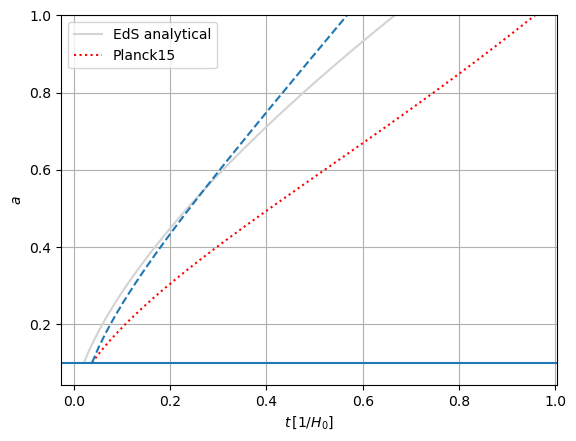

In [127]:
# plt.plot(t, a_avg, '-', label='Avera')
# plt.plot(t, snapshots, '--', label='EdS')

# This is wrong, because the EdS H0 and Planck15 H0 are the same at a = 1 but
# EdS H0 should be somewhere around 37
plt.plot((2/3) * a_vals**(3/2), a_vals, label='EdS analytical', color='lightgray')
# plt.plot(t_vals_H0_eds, a_vals_eds, 'g--', label='EdS astropy')

plt.plot(t_vals_H0, a_vals, 'r:', label='Planck15')

# The value of Eds H0 is 37.69 for Planck15 at a=1
# In this case Planck15 and EdS a(t) curves cross at a = 0.1


# plt.plot(t_vals_H0[0] + (t - t[0]), a_avg, '--')
plt.plot(t, a_avg, '--')

plt.axhline(0.1)

plt.legend()
plt.grid()
plt.xlabel(R'$t \, [1 / H_0]$')
plt.ylabel(R'$a$')
plt.ylim(None, 1)

In [128]:
snapshots.min(), snapshots.max()

(Array(0.1, dtype=float32), Array(1.05, dtype=float32))

In [129]:
a_vals_eds.min(), a_vals_eds.max()

(np.float64(0.1), np.float64(1.0))

In [130]:
H0_eds.to(u.Gyr**-1)

<Quantity 0.03854602 1 / Gyr>

In [131]:
((2/3) * snapshots **(3/2) / H0_eds.to(u.Gyr**-1)).min(), t_vals_eds.min(), t.min()

(Array(0.54692686, dtype=float32),
 <Quantity 0.54692677 Gyr>,
 Array(0.03777494, dtype=float32))

Text(0.5, 1.0, 'mesh_shape = [128, 128, 128], box_size = [96.0, 96.0, 96.0]')

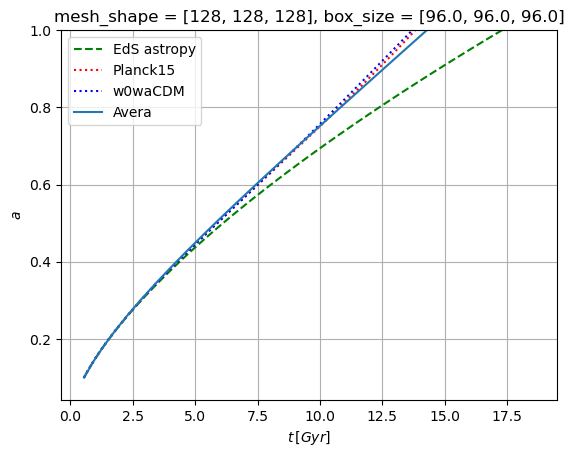

In [132]:
plt.plot(t_vals_eds, a_vals_eds, 'g--', label='EdS astropy')
plt.plot(t_vals, a_vals, 'r:', label='Planck15')
plt.plot(wowa_t_vals, wowa_a_vals, 'b:', label='w0waCDM')


# plt.plot(t, a_avg, '-', label='Avera')
plt.plot((2/3) * snapshots **(3/2) / H0_eds.to(u.Gyr**-1), a_avg, '-', label='Avera')

# plt.axhline(0.1)

plt.legend()
plt.grid()
plt.xlabel(R'$t \, [Gyr]$')
plt.ylabel(R'$a$')
plt.ylim(None, 1)
plt.title(f'mesh_shape = {mesh_shape}, box_size = {box_size}')

Text(0.5, 1.0, 'mesh_shape = [128, 128, 128], box_size = [96.0, 96.0, 96.0]')

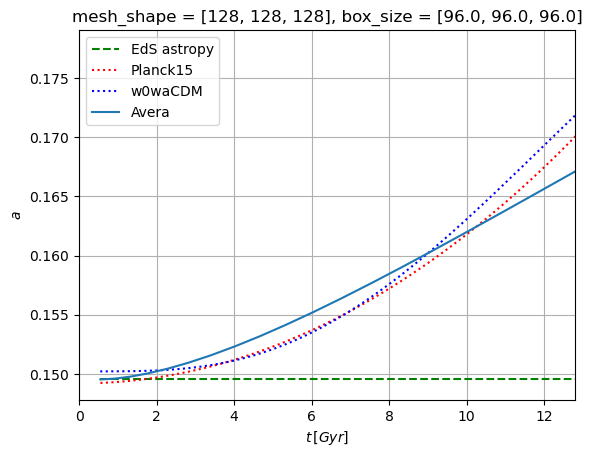

In [133]:
plt.plot(t_vals_eds, a_vals_eds / t_vals_eds**(2/3), 'g--', label='EdS astropy')
plt.plot(t_vals, a_vals / t_vals**(2/3), 'r:', label='Planck15')
plt.plot(wowa_t_vals, wowa_a_vals / wowa_t_vals**(2/3), 'b:', label='w0waCDM')


# plt.plot(t, a_avg, '-', label='Avera')
t = (2/3) * snapshots **(3/2) / H0_eds.to(u.Gyr**-1)
plt.plot(t, a_avg / t**(2/3), '-', label='Avera')

# plt.axhline(0.1)

plt.legend()
plt.grid()
plt.xlabel(R'$t \, [Gyr]$')
plt.ylabel(R'$a$')
plt.xlim(0, 12.8)
# plt.ylim(None, 1)
plt.title(f'mesh_shape = {mesh_shape}, box_size = {box_size}')

In [134]:
t_vals.min(), t_vals.max()

(<Quantity 0.5485607 Gyr>, <Quantity 13.82033644 Gyr>)

Text(0.5, 1.0, 'mesh_shape = [128, 128, 128], box_size = [96.0, 96.0, 96.0]')

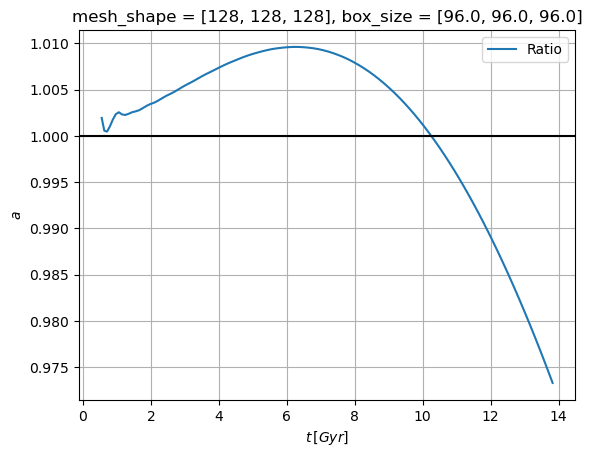

In [135]:
from scipy.interpolate import interp1d

t = (2/3) * snapshots **(3/2) / H0_eds.to(u.Gyr**-1)
lcdm_a_t = interp1d(t_vals, a_vals, bounds_error=False, fill_value=np.nan, kind='quadratic')
avera_a_t = interp1d(t, a_avg, bounds_error=False, fill_value=np.nan, kind='quadratic')

# plt.plot(t_vals, lcdm_a_t(t_vals), '-', label='LCDM')
# plt.plot(t_vals, avera_a_t(t_vals), '-', label='Avera')

plt.plot(t_vals, avera_a_t(t_vals) / lcdm_a_t(t_vals), '-', label='Ratio')

plt.axhline(1, color='black')

plt.legend()
plt.grid()
plt.xlabel(R'$t \, [Gyr]$')
plt.ylabel(R'$a$')
# plt.ylim(None, 1)
plt.title(f'mesh_shape = {mesh_shape}, box_size = {box_size}')

In [136]:
# Plot H/(1+z) as a function of z between z=0 and z=2.5
t_grid = np.linspace(t_vals.min(), t_vals.max(), 1000)

# time derivative of a_avg
a_dot_avera = np.diff(avera_a_t(t_grid)) / np.diff(t_grid)
a_dot_lcdm = np.diff(lcdm_a_t(t_grid)) / np.diff(t_grid)

Text(0, 0.5, 'H/(1+z)')

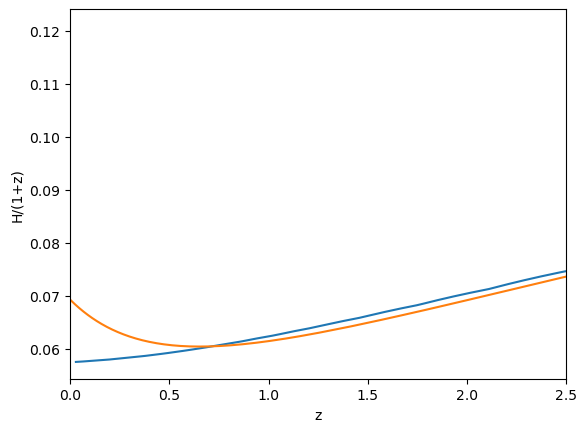

In [137]:
plt.plot(1 / avera_a_t(t_grid[:-1]) - 1, a_dot_avera)
plt.plot(1 / lcdm_a_t(t_grid[:-1]) - 1, a_dot_lcdm)
plt.xlim(0, 2.5)

plt.xlabel('z')
plt.ylabel('H/(1+z)')

(0.09, 0.6)

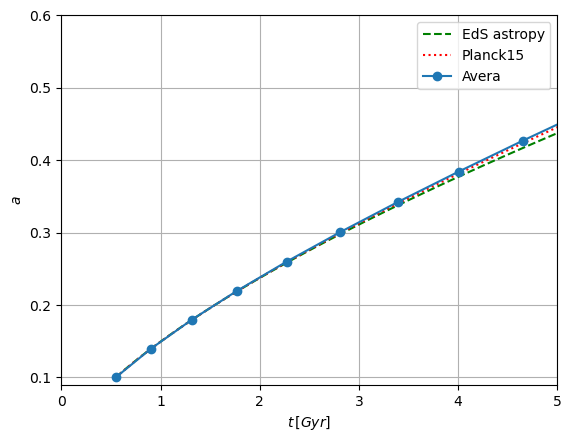

In [138]:
plt.plot(t_vals_eds, a_vals_eds, 'g--', label='EdS astropy')
plt.plot(t_vals, a_vals, 'r:', label='Planck15')


# plt.plot(t, a_avg, '-', label='Avera')
plt.plot((2/3) * snapshots **(3/2) / H0_eds.to(u.Gyr**-1), a_avg, '-o', label='Avera')

# plt.axhline(0.1)

plt.legend()
plt.grid()
plt.xlabel(R'$t \, [Gyr]$')
plt.ylabel(R'$a$')
plt.ylim(None, 1)

# plt.xlim(0, 2.5)
# plt.ylim(0.09, 0.3)

plt.xlim(0, 5)
plt.ylim(0.09, 0.6)

In [139]:
cic_paint(jnp.zeros(mesh_shape), lpt_particles).max()

Array(5.5579123, dtype=float32)

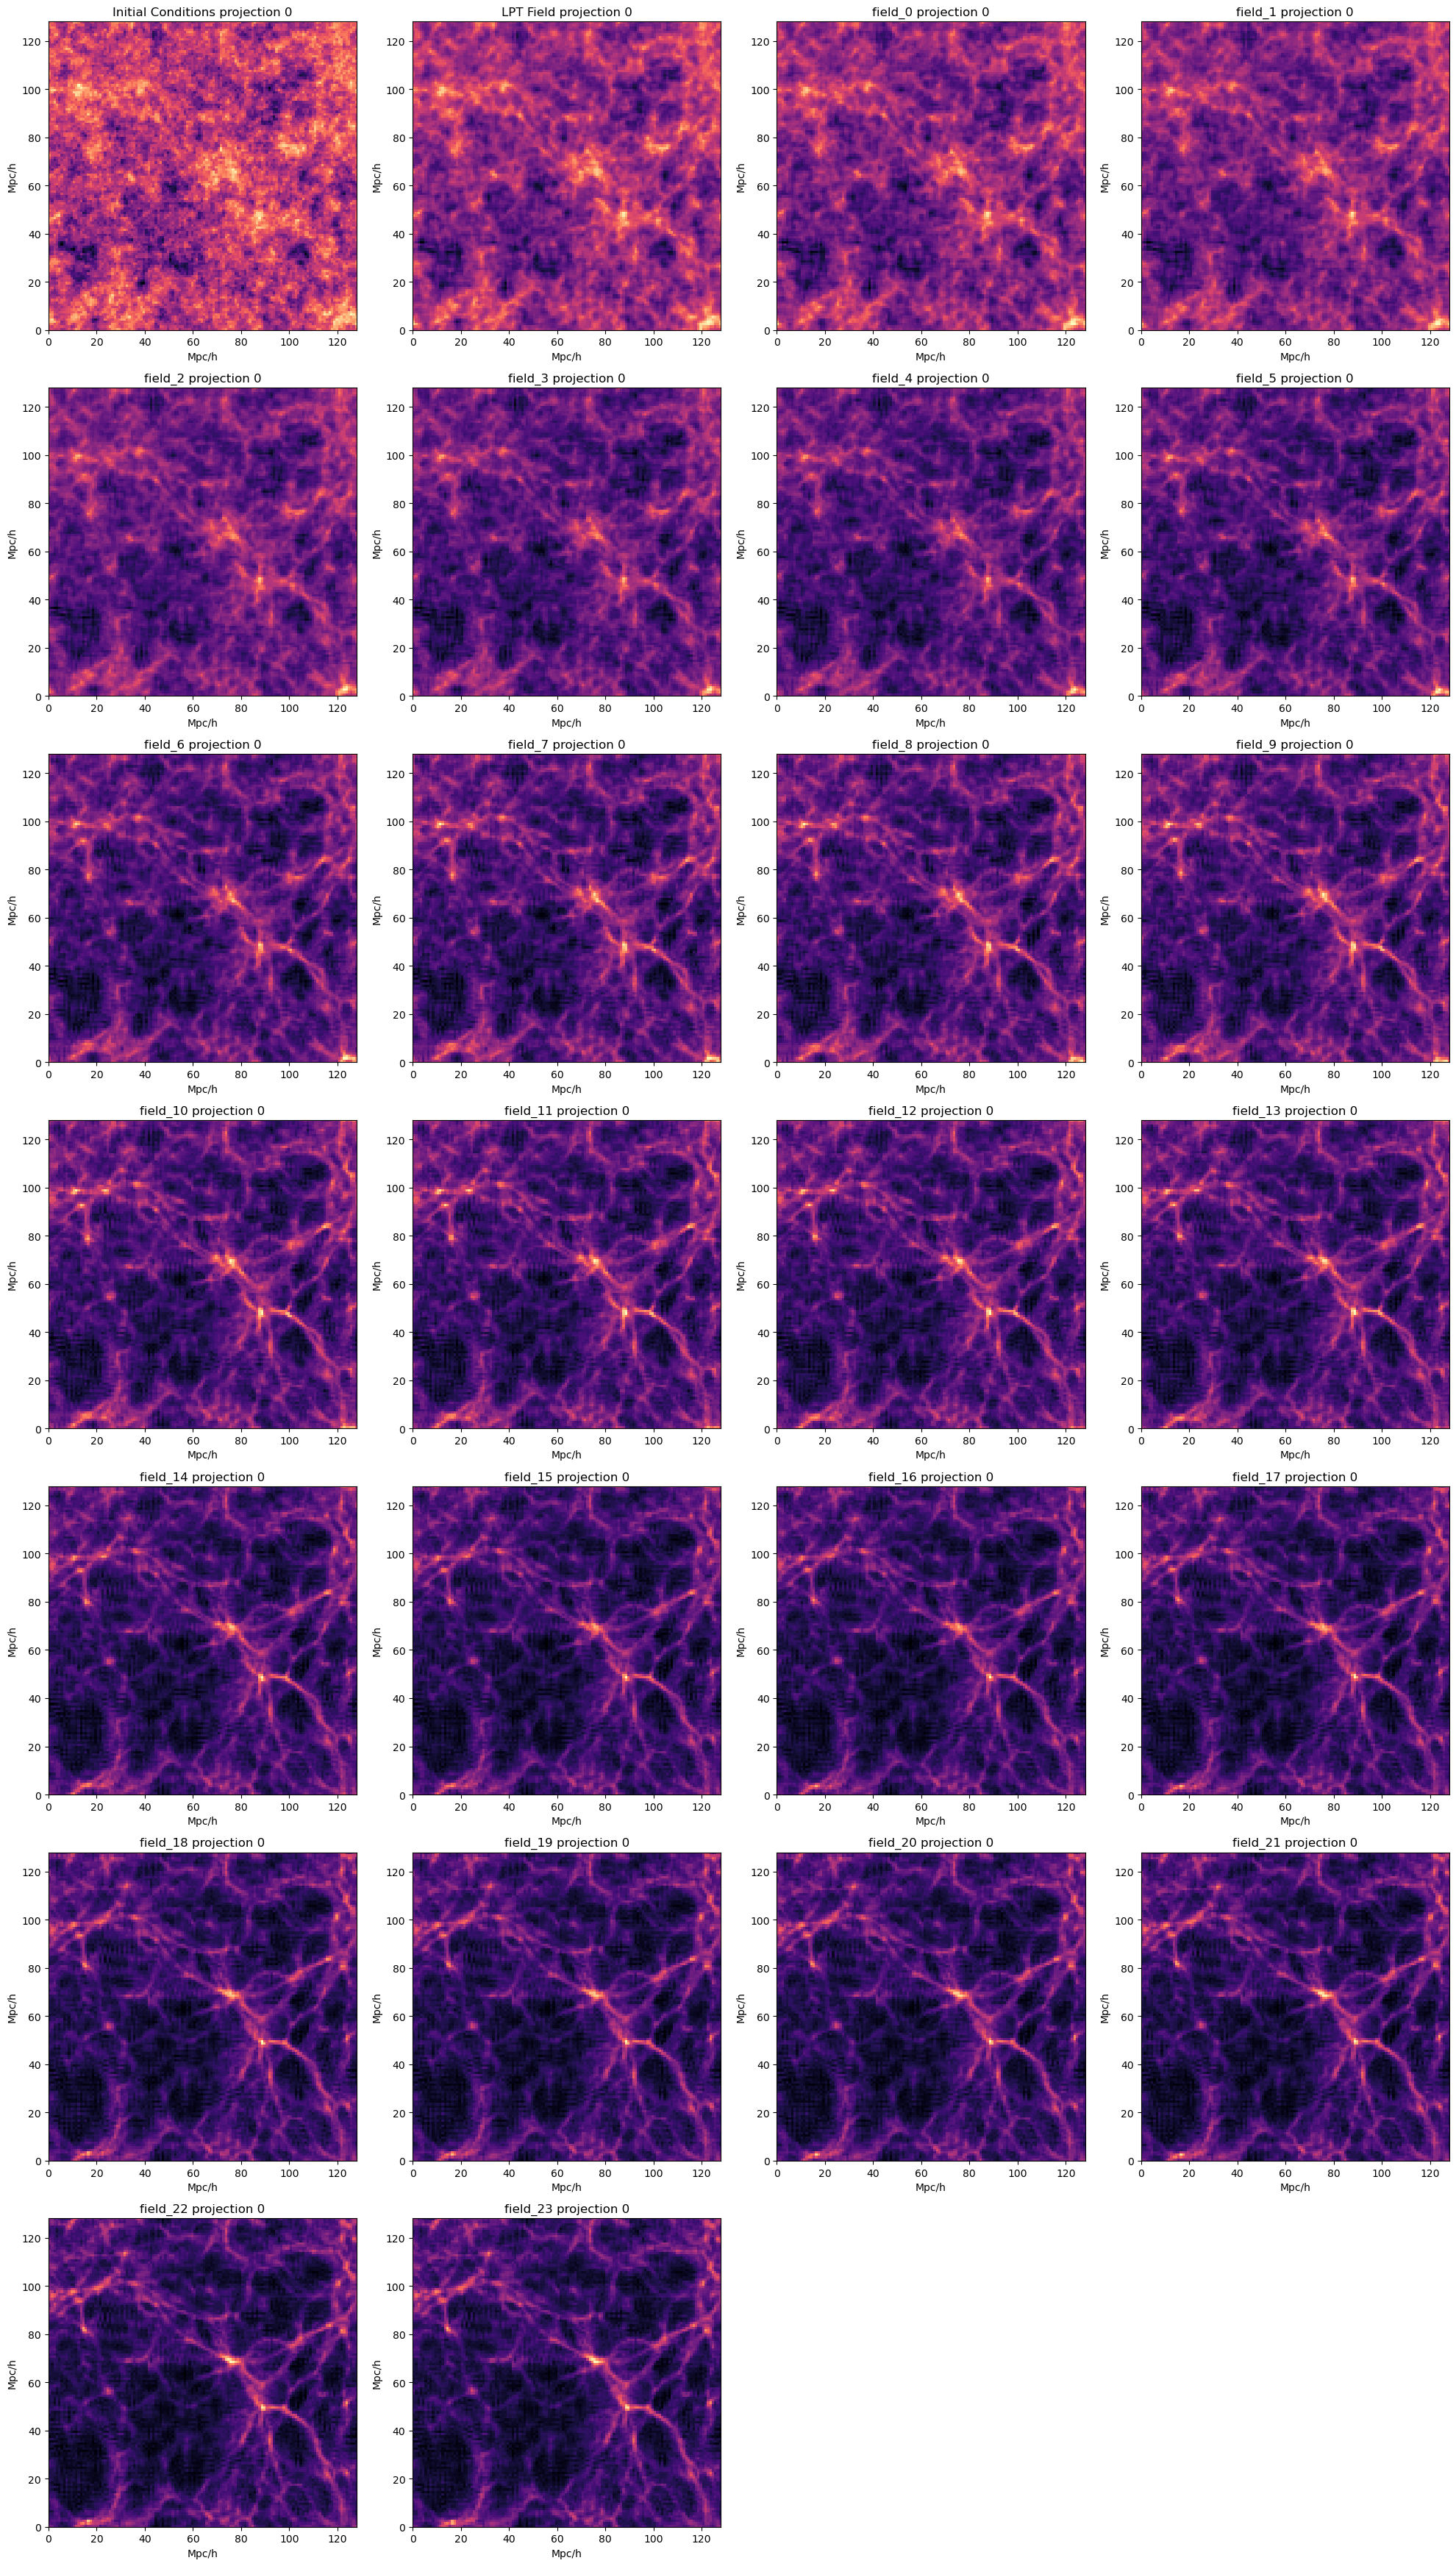

In [140]:
from jaxpm.plotting import plot_fields_single_projection

fields = {"Initial Conditions" : initial_conditions , "LPT Field" : jnp.log10(cic_paint(jnp.zeros(mesh_shape) ,lpt_particles) + 1)}
for i , field in enumerate(ode_particles[1:]):
    fields[f"field_{i}"] = jnp.log10(cic_paint(jnp.zeros(mesh_shape) , field)+1)
plot_fields_single_projection(fields)